# Section 3: Build, Train or Estimate the ML Model --> Chapter 12. Clustering

---
---

**Book: Applied Machine Learning for Data Science Practitioners**
<BR>

**Author:** Vidya Subramanian (https://www.linkedin.com/in/vidyas/)


**Note:** Code is only included here for the steps that require it. Please refer to the book for the complete set of steps related to the goals covered in the chapter.

---
---

---

☑ **Install libraries**

---

In [ ]:
# In case you need to install the relevent packages, please uncomment lines below and run (once only)

!pip install scikit-learn==1.2.2
!pip install pandas==2.0.3
!pip install numpy==1.25.2
!pip install matplotlib==3.7.1
!pip install pydrive2==1.6.3
!pip install IPython==7.34.0
!pip install seaborn==0.13.1
!pip install scipy==1.11.4
!pip install google.colab
!pip install oauth2client==4.1.3
!pip install xgboost==2.0.3
!pip install scikit-learn-extra


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 7.9 MB/s eta 0:00:00


---

☑ **Import libraries**

---

In [ ]:
# Set some common environment variables and Imports
import numpy as np
import pandas as pd
import warnings
import re
import time
import textwrap

from IPython.core.display import display, HTML
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN, OPTICS, MeanShift
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt
import seaborn as sns

from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
display(HTML("<style>.container { width:100% !important; }</style>"))

#4. Clustering Algorithms

## 4.1. Hierarchy-Based Clustering



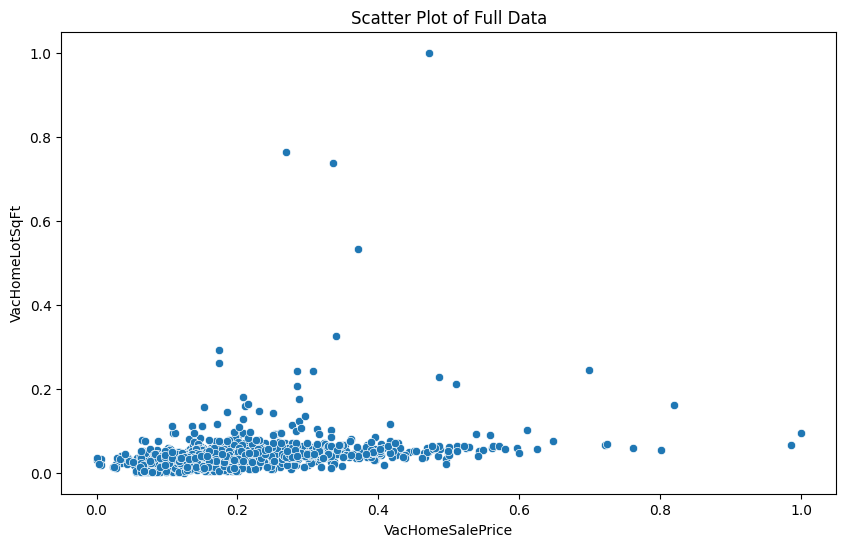

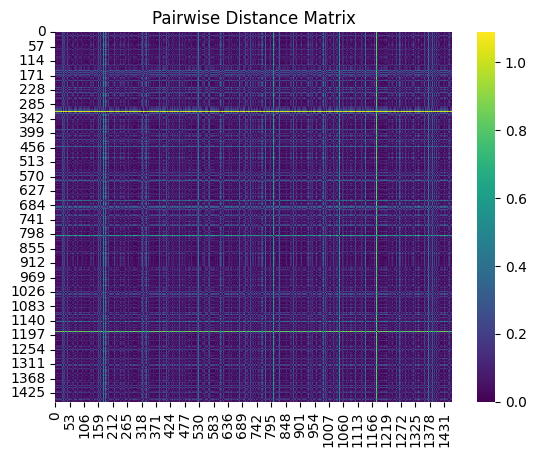

####################################################################################################

                                 Hierarchical Clustering Dendrogram                                 

####################################################################################################



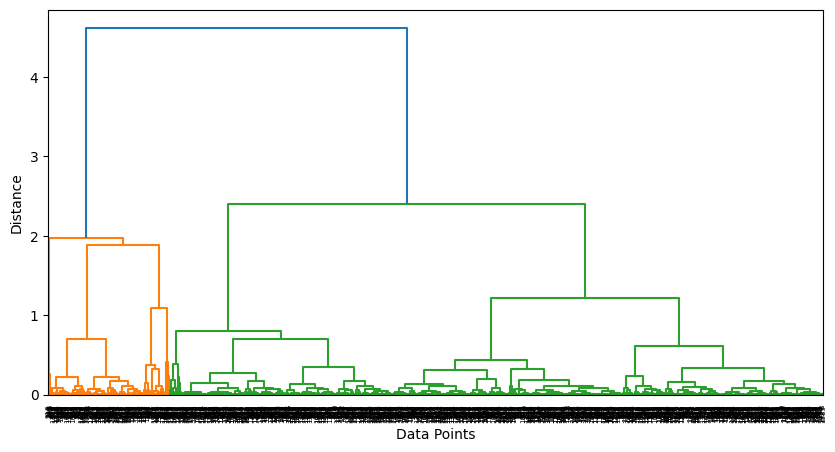

####################################################################################################

                            Truncated Hierarchical Clustering Dendrogram                            

####################################################################################################



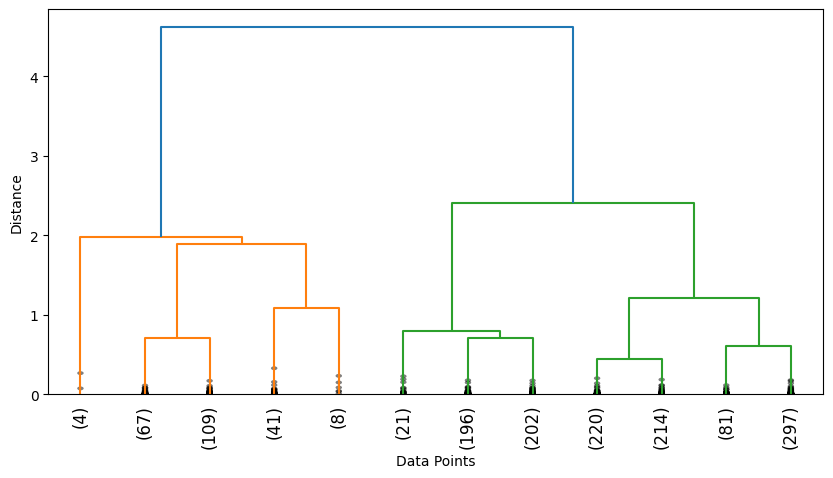

(VacHomeSalePrice > 0.09407570407550084 AND VacHomeSalePrice < 0.1696194963037568)
(VacHomeLotSqFt > 0.01629112348433555 AND VacHomeLotSqFt < 0.050585658875478626)
(Cluster > 3.0 AND Cluster < 3.0)
(VacHomeSalePrice > 0.2017549869260656 AND VacHomeSalePrice < 0.2639074658160124)
(VacHomeLotSqFt > 0.01403851379840168 AND VacHomeLotSqFt < 0.08363653495473236)
(Cluster > 2.0 AND Cluster < 2.0)
(VacHomeSalePrice > 0.2867561687973383 AND VacHomeSalePrice < 0.511854152791912)
(VacHomeLotSqFt > -0.031793408255408856 AND VacHomeLotSqFt < 0.16526443359034937)
(Cluster > 1.0 AND Cluster < 1.0)
####################################################################################################

                                         New Optimized Rule                                         

####################################################################################################

(VacHomeSalePrice>0.09  AND  VacHomeSalePrice<0.17) OR (VacHomeLotSqFt>0.02  AND
VacHomeLotSqFt<0.05) T

In [ ]:
# ***** Function to help display*****
def print_pretty_header(title, subtitle):
    # Define header formatting
    line_length = 50
    header_padding = 2
    # Calculate the width for the title text
    title_width = line_length  * header_padding
    print("#" * title_width + "\n")
    print(title.center(title_width) + "\n")
    if subtitle:
        # Calculate the width for the subtitle text
        subtitle_width = line_length - 2 * header_padding
        print(subtitle.center(title_width)+ "\n")
    print("#" * title_width + "\n")

# Function to Retrieve Training Data
def _1_get_data():
    auth.authenticate_user()
    gauth = GoogleAuth()
    gauth.credentials = GoogleCredentials.get_application_default()
    drive = GoogleDrive(gauth)

    colabFileName = 'S2_Ch6_Data_Quality_Engineering_data.csv'
    dataLink = 'https://drive.google.com/open?id=1h_Akm5JR06mz0yeM5jmhTfbOBDJngifp'  # The shareable link to the file
    ignorestr, id = dataLink.split('=')  # Split the link by '=' and get the id of the file
    downloaded = drive.CreateFile({'id':id})  # Create a PyDrive File instance with the specified file id
    downloaded.GetContentFile(colabFileName)  # Download the file and save it to the local file system
    df_rawdata = pd.read_csv(colabFileName)  # Read the CSV file into a Pandas dataframe
    pd.set_option('display.max_columns', None)
    return df_rawdata

# Function to Define Variables
def _2_define_variables():
    cluster_evaluation_columns = ['Data', 'Algorithm', 'Silhouette Score', 'Davies-Bouldin Index',
                                   'Cophenetic Correlation Coefficient', 'Calinski-Harabasz Index', 'Duration']
    cluster_columns =  ['VacHomeSalePrice','VacHomeLotSqFt']
    return cluster_evaluation_columns, cluster_columns

# Functions for Data Processing and Encoding
def _3_preprocess_data(df_rawdata, cluster_columns):
    # Assuming df is your DataFrame
    preprocessed_data = df_rawdata.dropna(subset=cluster_columns)
    preprocessed_data = preprocessed_data[cluster_columns]
    return preprocessed_data

def _4_encode_data(preprocessed_data):
    # Initialize MinMaxScaler
    scaler = MinMaxScaler()

    # Fit and transform the data
    scaled_data = scaler.fit_transform(preprocessed_data)

    # Convert the scaled data back to a DataFrame
    scaled_df = pd.DataFrame(scaled_data, columns=preprocessed_data.columns)
    return scaled_df

# Define Function for Hierarchical Clustering
def _5_hierarchical_clustering(pca_data, clustering_linkage):
    clusters = linkage(pca_data, clustering_linkage, metric='euclidean')
    # Extract cluster labels using fcluster
    max_d = 100000  # Adjust this threshold as needed
    cluster_labels = fcluster(clusters, max_d, criterion='maxclust')
    return clusters, cluster_labels

# Define Function to Plot Dendrogram
def _6_plot_dendrogram(clusters, title="Home Prices Dendrogram"):
    # Plot dendrogram
    print_pretty_header("Hierarchical Clustering Dendrogram", "")
    plt.figure(figsize=(10, 5))
    dendrogram(clusters)
    # plt.title('Hierarchical Clustering Dendrogram')
    plt.xlabel('Data Points')
    plt.ylabel('Distance')
    plt.show()

    # Cut the dendrogram to get a specific number of clusters
    print_pretty_header("Truncated Hierarchical Clustering Dendrogram", "")
    max_d = 20  # Set the threshold height
    plt.figure(figsize=(10, 5))
    dendrogram(clusters, truncate_mode='lastp', p=12, show_leaf_counts=True, leaf_rotation=90., leaf_font_size=12., show_contracted=True)
    # plt.title('Hierarchical Clustering Dendrogram (truncated)')
    plt.xlabel('Data Points')
    plt.ylabel('Distance')
    plt.axhline(y=max_d, c='k')
    plt.show()

# Step 7. Extract Rules
def _7_extract_cluster_rules(encoded_data, num_clusters, column_names, linkage_method):
    metric='distance'
    # Convert data to DataFrame if it's a NumPy array
    if isinstance(encoded_data, np.ndarray):
        encoded_data = pd.DataFrame(encoded_data, columns=[f'Feature_{i}' for i in range(encoded_data.shape[1])])

    # Perform hierarchical clustering
    clusters = linkage(encoded_data, linkage_method, metric="euclidean")

    # Cut the dendrogram to get clusters
    cluster_labels = fcluster(clusters, num_clusters, criterion='maxclust')

    rules = []

    for cluster_id in range(1, num_clusters + 1):
        # Extract data points in the current cluster
        cluster_data = encoded_data.loc[cluster_labels == cluster_id]

        # print(f"Cluster {cluster_id} data:")
        # print(cluster_data)

        if not cluster_data.empty:  # Check if there are data points in the cluster
            # Generate rules based on mean and standard deviation
            for column in column_names:
                mean_val = cluster_data[column].mean()
                std_val = cluster_data[column].std()

                # Check if there's more than one data point in the cluster before calculating std
                if len(cluster_data) > 1:
                    # print(f"Standard deviation for {column}: {std_val}")

                    rule_greater = f"{column} > {mean_val - std_val}"
                    rule_less = f"{column} < {mean_val + std_val}"

                    rules.append(rule_greater)
                    rules.append(rule_less)
                else:
                    print(f"Skipping standard deviation calculation for {column} due to only one data point in the cluster.")

        else:
            # If there are no data points in the cluster, skip generating rules for it
            continue

    # Combine rules using AND, OR, and NOT
    combined_rules = []
    for i in range(0, len(rules), 2):
        combined_rule = f"({rules[i]} AND {rules[i + 1]})"
        combined_rules.append(combined_rule)

    return combined_rules

def main():

    # 0. Start the timer
    start_time = time.time()

    # Step 1. Get Data
    df_rawdata = _1_get_data()

    # Step 2. Sort the variables by data type for easier encoding
    cluster_evaluation_columns, cluster_columns = _2_define_variables()
    cluster_result_df = pd.DataFrame(columns=cluster_evaluation_columns)

    # Step 3. Preprocess data
    preprocessed_data = _3_preprocess_data(df_rawdata, cluster_columns)

    # Step 5. Encode data (Standardize using Min-Max scaling)
    scaled_data = _4_encode_data(preprocessed_data)

    # Perform hierarchical clustering

    linkage_method = "ward"

    # Calculate pairwise distances
    pairwise_distances = pdist(scaled_data)

    # Perform hierarchical clustering
    clusters, cluster_labels = _5_hierarchical_clustering(pairwise_distances, linkage_method)

    # Print the number of clusters
    num_clusters = len(set(cluster_labels))

    # Step 8. Plot Dendrogram
    cluster_threshold = 3  # Set the threshold or the number of clusters
    scaled_data['Cluster'] = fcluster(clusters, cluster_threshold, criterion='maxclust')

    # Scatter plot of full data
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=scaled_data.iloc[:, 0], y=scaled_data.iloc[:, 1])
    plt.title("Scatter Plot of Full Data")
    plt.xlabel("VacHomeSalePrice")
    plt.ylabel("VacHomeLotSqFt")
    plt.show()

    # Show pairwise distance matrix
    dist_matrix = squareform(pairwise_distances)
    sns.heatmap(dist_matrix, cmap="viridis")
    plt.title("Pairwise Distance Matrix")
    plt.show()

    _6_plot_dendrogram(clusters, title="Home Prices Dendrogram")

    # Corrected function call
    rules = _7_extract_cluster_rules(scaled_data, cluster_threshold, scaled_data.columns, linkage_method)

    # Group data by cluster labels
    cluster_groups = scaled_data.groupby('Cluster')

    # List to store rounded rules
    rounded_rules = []

    # Define a regex pattern to match column names
    column_pattern = re.compile(r'\b[A-Za-z0-9_]+\b')

    # Function to round numerical values in a rule
    def round_numerical_values(rule):
        return re.sub(r'([-+]?\d*\.\d+|\d+)', lambda x: f"{float(x.group()):.2f}", rule)

    for rule in rules:
      print(rule)
      # Extract column names from the rule
      columns = column_pattern.findall(rule)
      # Round numerical values in the rule
      rounded_rule = round_numerical_values(rule)
      rounded_rules.append(rounded_rule)

    # Combine rules
    combined_rule = " OR ".join(rounded_rules)
    combined_rule = combined_rule.replace("AND", " AND ")

    # Optimize rules (if needed)
    optimized_rule = combined_rule.replace(" > ", ">").replace(" < ", "<")

    # print_pretty_header("Combined and Optimized Rule", "")
    # print(optimized_rule)

    # Define a regular expression pattern to match "(Cluster > X.0 AND Cluster < X.0)"
    pattern = r'OR \(Cluster>(\d+\.\d+)  AND  Cluster<(\d+\.\d+)\)'

    # Replacement string with escaped backslashes
    replacement = r'THEN Cluster = \1'
    replacement = re.sub(r'.00', '', replacement)

    # Perform the substitution
    new_optimized_rule = re.sub(pattern, replacement, optimized_rule)
    wrapped_rule = "\n".join(textwrap.wrap(new_optimized_rule, width=100))
    print_pretty_header("New Optimized Rule", "")
    print(wrapped_rule)
    return

if __name__ == "__main__":
    main()  # Call main() and store the result in binary_result_df
    # cluster_result_df  # Now you can access binary_result_df


## 4.2. Other Clustering



####################################################################################################

                                       Clustering Algorithms                                        

####################################################################################################



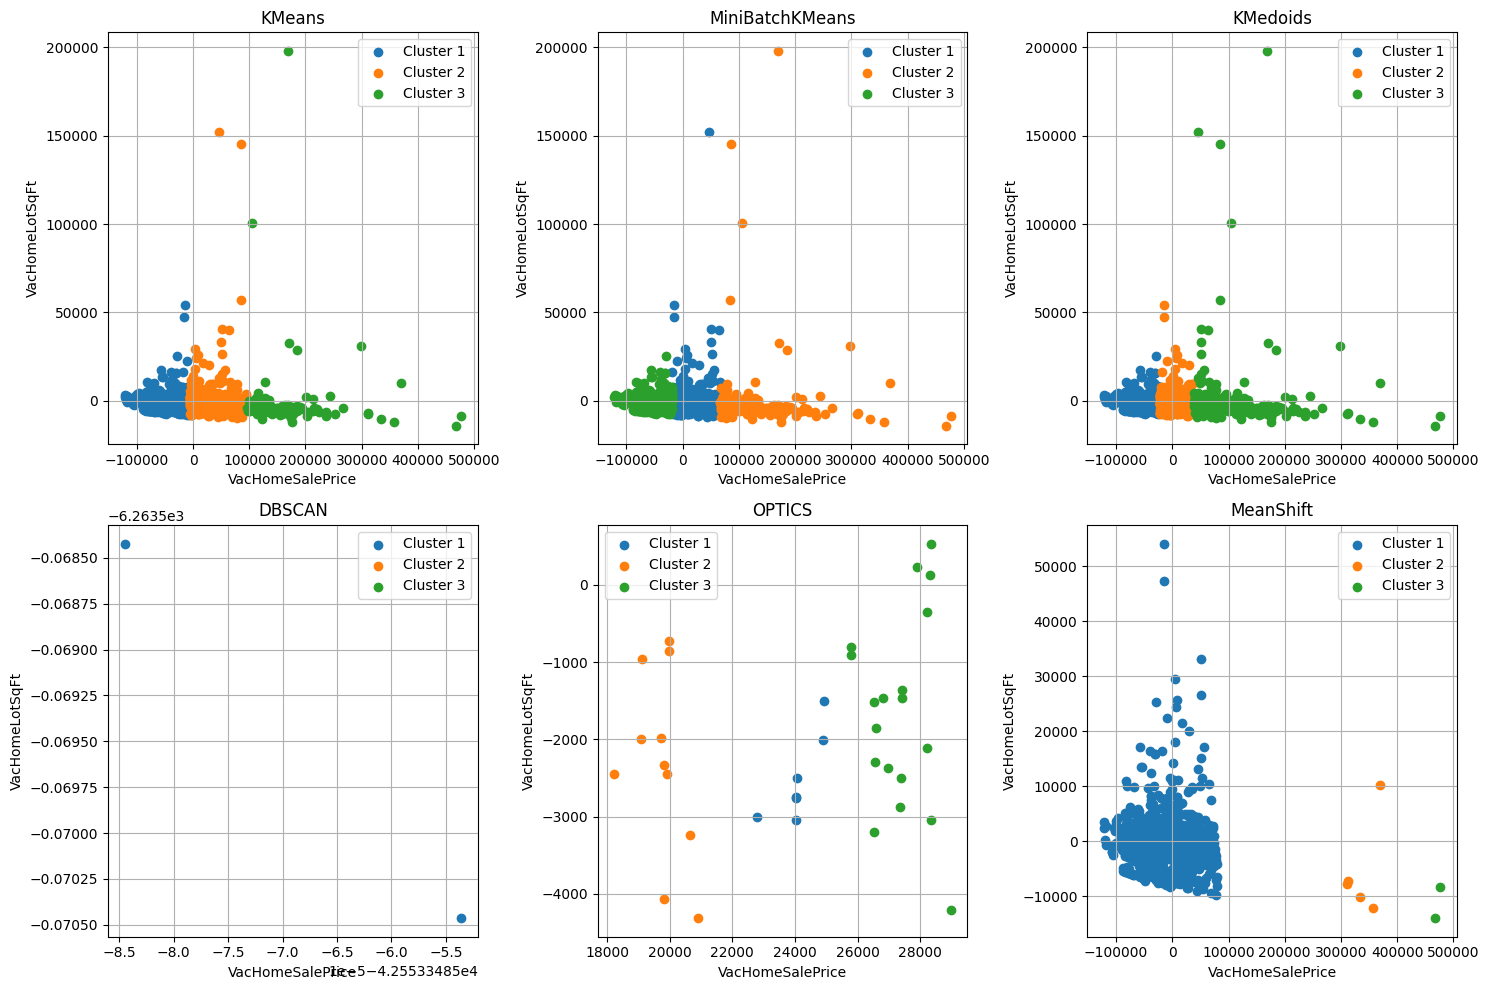

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN, OPTICS, MeanShift
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import pandas as pd
import numpy as np
import time
import re
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# Local Imports and variables
n_neighbors = [1, 3, 5]  # List of integers to loop through for KNN

# ***** Function to help display*****
def print_pretty_header(title, subtitle):
    # Define header formatting
    line_length = 50
    header_padding = 2
    # Calculate the width for the title text
    title_width = line_length * header_padding
    print("#" * title_width + "\n")
    print(title.center(title_width) + "\n")
    if subtitle:
        # Calculate the width for the subtitle text
        subtitle_width = line_length - 2 * header_padding
        print(subtitle.center(title_width) + "\n")
    print("#" * title_width + "\n")

# Function to Retrieve Training Data
def _1_get_data():
    auth.authenticate_user()
    gauth = GoogleAuth()
    gauth.credentials = GoogleCredentials.get_application_default()
    drive = GoogleDrive(gauth)

    colabFileName = 'S2_Ch6_Data_Quality_Engineering_data.csv'
    dataLink = 'https://drive.google.com/open?id=1h_Akm5JR06mz0yeM5jmhTfbOBDJngifp'  # The shareable link to the file
    ignorestr, id = dataLink.split('=')  # Split the link by '=' and get the id of the file
    downloaded = drive.CreateFile({'id': id})  # Create a PyDrive File instance with the specified file id
    downloaded.GetContentFile(colabFileName)  # Download the file and save it to the local file system
    df_rawdata = pd.read_csv(colabFileName)  # Read the CSV file into a Pandas dataframe
    pd.set_option('display.max_columns', None)
    return df_rawdata

# Function to Define Variables
def _2_define_variables():
    cluster_evaluation_columns = [ 'Algorithm', 'Silhouette Score', 'Davies-Bouldin Index',
                                  'Calinski-Harabasz Index', 'Duration']

    continuous_columns = [
        'VacHomeLotFrontage', 'VacHomeLotSqFt', 'VacHomeBsmtSqFt', 'VacHomeFloor1SqFt',
        'VacHomeFloor2SqFt', 'VacHomeSqFt', 'VacHomeGarageArea', 'VacHomeWoodDeckSqFt', 'VacHomePorchSqFt',
        'VacHomePoolSqFt', 'VacHomeSalePrice', 'VacHomeMasonryArea', 'VacHomeRenovationAmount'
    ]

    nominal_columns = [
        'VacHomeLotShape', 'VacHomeLandContour', 'VacHomeLotConfig', 'VacHomeLandSlope',
        'VacHomeNeighborhood', 'VacHomeCondition', 'VacHomeBuilding', 'VacHomeRoofStyle',
        'VacHomeMasonryVeneer', 'VacHomeFoundation', 'VacHomeBsmtLight', 'VacHomeBsmtFinish',
        'VacHomeAC', 'VacHomeGarageType', 'VacHomeGarageFinish', 'VacHomeDriveway', 'VacHomeFence',
        'VacHomeSaleCondition', 'VacHomeGoodSchools', 'VacHomeOwnerGender', 'VacHomeOwnerState', 'VacHomeInterestInHome'
    ]

    ordinal_columns = [
        'VacHomeRating', 'VacHomeQuality', 'VacHomeExterQual', 'VacHomeQual', 'VacHomeBsmtQuality',
        'VacHomeHeatingQuality', 'VacHomeFireplaceQuality', 'VacHomeGarageQuality', 'VacHomeSurveyRating'
    ]

    ignore_columns = [
        'VacationHomeID', 'VacHomeStreet', 'VacHomeRoad', 'VacHomeConsYear', 'VacHomeSince',
        'VacHomeStartMonth', 'VacHomeStartYear', 'VacHomeAvailableDate', 'VacHomeBarCode',
        'VacHomeOwnerAddress', 'VacHomeOwnerEmail', 'VacHomeSurveyDate', 'VacHomeNumFullBath',
        'VacHomeNumHalfBath', 'VacHomeBedroomWithCloset', 'VacHomeKitcheninHome', 'VacHomeRooms',
        'VacHomeFireplaces', 'VacHomeCarsInGarage', 'VacHomeClass', 'VacHomeExterior', 'VacHomeSaleType',
        'VacHomeHouseStyle', 'VacHomeUtilities', 'VacHomeElectricalWiring', 'VacHomeZone', 'VacHomeHeating',
        'VacHomeOwnerZipcode', 'VacHomeRoofMat', 'VacHomeOwnerCity', 'VacHomeOwnerCountry', 'VacHomePoolQuality',
        'VacHomeKitchenQuality', 'VacHomeReviewDate'
    ]
    return cluster_evaluation_columns, continuous_columns, nominal_columns, ordinal_columns, ignore_columns

# Function to preprocess data
def _3_preprocess_data(df_rawdata, continuous_columns, nominal_columns, ordinal_columns, ignore_columns):
    preprocessed_data = df_rawdata.copy()
    for col in continuous_columns:
        preprocessed_data[col].fillna(preprocessed_data[col].mean(), inplace=True)

    for col in nominal_columns:
        preprocessed_data[col].fillna("Unknown", inplace=True)

    for col in ordinal_columns:
        preprocessed_data[col].fillna(15, inplace=True)
        preprocessed_data[col] = ['N' if label == '0' else label for label in preprocessed_data[col]]

    preprocessed_data = preprocessed_data.drop(columns=ignore_columns)
    return preprocessed_data

# Function to Encode Data
def _4_encode_data(preprocessed_data, continuous_columns, nominal_columns, ordinal_columns, ignore_columns):
    label_encoder = LabelEncoder()
    encoded_data = preprocessed_data.copy()
    for col in ordinal_columns:
        encoded_data[col] = label_encoder.fit_transform(encoded_data[col].astype(str))

    for col in nominal_columns:
        if col in encoded_data.columns:
            encoded_data[col] = label_encoder.fit_transform(encoded_data[col])

    encoded_data = pd.get_dummies(encoded_data, columns=nominal_columns, drop_first=True)
    return encoded_data

# Function to run PCA
def _5_run_pca(encoded_data, n_components=2):
    # Initialize PCA and fit on your data
    pca = PCA(n_components=n_components)
    pca_data = pca.fit_transform(encoded_data)

    # Identify the most influential features for each principal component
    most_influential_features = []
    for i in range(n_components):
        component = pca.components_[i]
        abs_component = np.abs(component)
        most_influential_feature_idx = np.argmax(abs_component)
        most_influential_feature = encoded_data.columns[most_influential_feature_idx]
        most_influential_features.append(most_influential_feature)

    pca_df = pd.DataFrame(data=pca_data, columns=most_influential_features)
    return pca_df, most_influential_features

# Function to append clustering results
def _6_append_clustering_df(clustering_result_df, data, clf_name, labels_pred, duration):
    if len(set(labels_pred)) > 1:
        silhouette = silhouette_score(data, labels_pred)
    else:
        silhouette = np.nan

    new_row = {
        'Algorithm': clf_name,
        'Silhouette Score': silhouette,
        'Calinski-Harabasz Index': calinski_harabasz_score(data, labels_pred),
        'Davies-Bouldin Index': davies_bouldin_score(data, labels_pred),
        'Duration': duration
    }
    clustering_result_df = pd.concat([clustering_result_df, pd.DataFrame([new_row])], ignore_index=True)
    return clustering_result_df

# Define a function to plot all clusters in a 2x3 grid
def _7_plot_all_clusters(cluster_data, num_clusters, algo_names, labels_list, feature_names):
    print_pretty_header("Clustering Algorithms", "")
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, (algo_name, labels) in enumerate(zip(algo_names, labels_list)):
        ax = axes[i]
        for cluster in range(num_clusters):
            ax.scatter(cluster_data[labels == cluster][:, 0], cluster_data[labels == cluster][:, 1], label=f'Cluster {cluster + 1}')
        ax.set_title(algo_name)
        ax.set_xlabel(feature_names[0])
        ax.set_ylabel(feature_names[1])
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()

# Define Main Workflow
def main():
    # 0. Start the timer
    start_time = time.time()

    # Step 1. Get Data
    df_rawdata = _1_get_data()

    # Step 2. Sort the variables by data type for easier encoding
    cluster_evaluation_columns, continuous_columns, nominal_columns, ordinal_columns, ignore_columns = _2_define_variables()
    cluster_result_df = pd.DataFrame(columns=cluster_evaluation_columns)

    # Step 3. Preprocess data
    preprocessed_data = _3_preprocess_data(df_rawdata, continuous_columns, nominal_columns, ordinal_columns, ignore_columns)

    # Step 4. Encode data
    encoded_data = _4_encode_data(preprocessed_data, continuous_columns, nominal_columns, ordinal_columns, ignore_columns)

    # Step 5. Run PCA for dimensionality reduction
    pca_df, feature_names = _5_run_pca(encoded_data, n_components=2)

    # Define clustering metrics
    clustering_metrics = [silhouette_score, davies_bouldin_score]

    # Define number of clusters
    num_of_clusters = 3

    # Define algorithms
    clustering_algos = {
        'KMeans': KMeans(n_clusters=num_of_clusters),
        'MiniBatchKMeans': MiniBatchKMeans(n_clusters=num_of_clusters),
        'KMedoids': KMedoids(n_clusters=num_of_clusters),
        'DBSCAN': DBSCAN(eps=0.01, min_samples=2),
        'OPTICS': OPTICS(min_samples=5),
        'MeanShift': MeanShift(bandwidth=None, cluster_all=True)
    }

    algo_names = []
    labels_list = []

    clustering_result_df = pd.DataFrame(columns=cluster_evaluation_columns)

    # Perform clustering with each algorithm
    for algo_name, algo in clustering_algos.items():

        start_time_algo = time.time()
        labels_pred = algo.fit_predict(pca_df)

        # Check if there's only one cluster or no clustering performed
        if len(np.unique(labels_pred)) <= 1:
            print(f"Warning: Algorithm {algo_name} produced only one cluster or no clusters.")
            continue

        end_time_algo = time.time()
        duration = round(end_time_algo - start_time_algo, ndigits=4)

        # Append results to the clustering result DataFrame
        clustering_result_df = _6_append_clustering_df(clustering_result_df, pca_df, algo_name, labels_pred, duration)

        # Store the algorithm name and labels for plotting
        algo_names.append(algo_name)
        labels_list.append(labels_pred)

    # Plot all clusters in a 2x3 grid
    _7_plot_all_clusters(pca_df.values, num_of_clusters, algo_names, labels_list, feature_names)

    return clustering_result_df

if __name__ == "__main__":
    cluster_result_df = main()  # Call main() and store the result in cluster_result_df


In [ ]:
# Format specific columns as percentages
score_columns = ['Silhouette Score','Davies-Bouldin Index' ,'Calinski-Harabasz Index']
cluster_result_df[score_columns] = cluster_result_df[score_columns].applymap(lambda x: f"{x:.2f}")
print_pretty_header("Clustering Algorithms Results", "")
cluster_result_df

####################################################################################################

                                   Clustering Algorithms Results                                    

####################################################################################################



,Algorithm,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Duration
0,KMeans,0.55,0.60,2373.78,2.8778
1,MiniBatchKMeans,0.54,0.60,2373.19,0.9688
2,KMedoids,0.49,0.64,1848.40,0.3151
3,DBSCAN,-0.32,1.13,0.83,0.0102
4,OPTICS,-0.20,2.99,10.68,1.1499
5,MeanShift,0.58,0.32,385.28,7.5283
